In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from scipy.interpolate import UnivariateSpline



# Set consistent style
plt.style.use('default')
fig_size_x = 7
fig_size_y = 4
plt.rcParams['font.size'] = 10

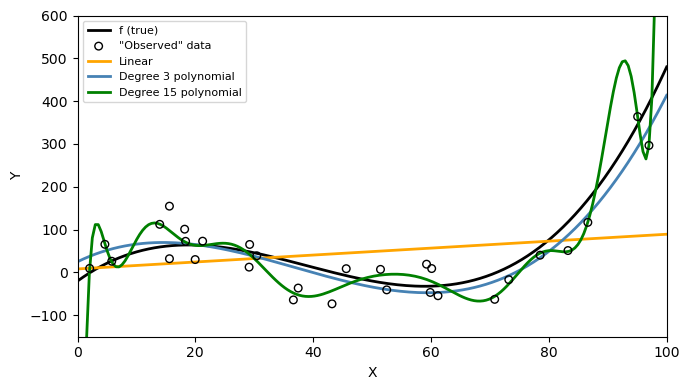

In [2]:
#| echo: false

np.random.seed(42)

n=30
# True function: third degree polynomial
def true_f(x):
    return 0.003*x**3 - 0.35*x**2 + 10*x - 20

x = np.linspace(0, 100, 200)
x_obs = np.random.uniform(0, 100, n)
y_obs = true_f(x_obs) + np.random.normal(0, 50, n)

# # Three fits
# Linear fit
lin_model = LinearRegression()
lin_model.fit(x_obs.reshape(-1, 1), y_obs)
y_linear = lin_model.predict(x.reshape(-1, 1))

# Degree 3 polynomial (matches true f)
coeffs3 = np.polyfit(x_obs, y_obs, 3)
y_poly3 = np.polyval(coeffs3, x)

# Degree 15 polynomial (overfitting)
t_min, t_max = x_obs.min(), x_obs.max()
x_norm = (x_obs - t_min) / (t_max - t_min)
x_line_norm = (x - t_min) / (t_max - t_min)
coeffs15 = np.polyfit(x_norm, y_obs, 15)
y_poly15 = np.polyval(coeffs15, x_line_norm)

plt.figure(figsize=(fig_size_x, fig_size_y))
plt.plot(x, true_f(x),  'k-',          linewidth=2, label='f (true)')
plt.scatter(x_obs, y_obs, s=30, facecolors='none', edgecolors='black', zorder=5, label='"Observed" data')
plt.plot(x, y_linear,   color='orange',    linewidth=2, label='Linear')
plt.plot(x, y_poly3,    color='steelblue', linewidth=2, label='Degree 3 polynomial')
plt.plot(x, y_poly15,   color='green',     linewidth=2, label='Degree 15 polynomial')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

In [3]:
print(y_poly15.min(), y_poly15.max())

-1577.2941020317169 4315.274085828513


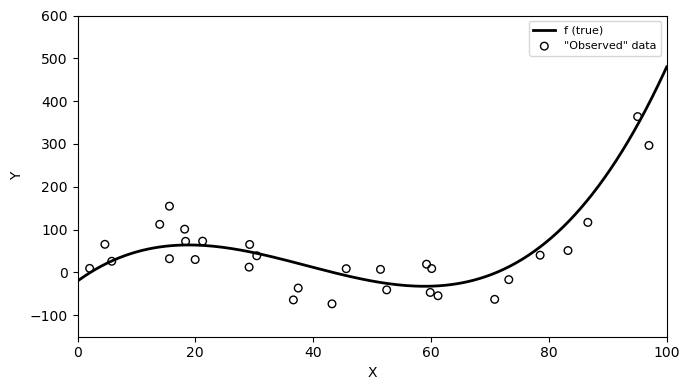

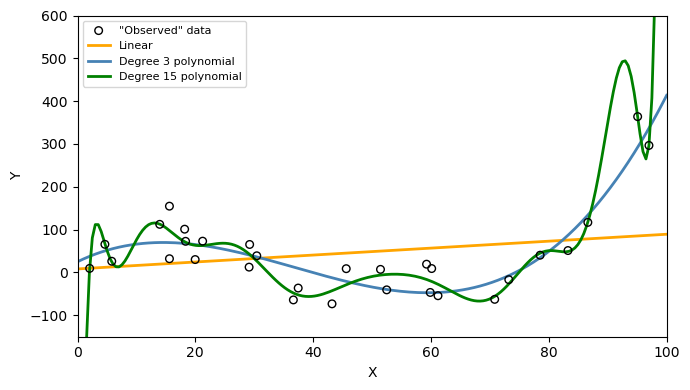

In [4]:
np.random.seed(42)

n=30
# True function: third degree polynomial
def true_f(x):
    return 0.003*x**3 - 0.35*x**2 + 10*x - 20

x = np.linspace(0, 100, 200)
x_obs = np.random.uniform(0, 100, n)
y_obs = true_f(x_obs) + np.random.normal(0, 50, n)

# # Three fits
# Linear fit
lin_model = LinearRegression()
lin_model.fit(x_obs.reshape(-1, 1), y_obs)
y_linear = lin_model.predict(x.reshape(-1, 1))

# Degree 3 polynomial (matches true f)
coeffs3 = np.polyfit(x_obs, y_obs, 3)
y_poly3 = np.polyval(coeffs3, x)

# Degree 15 polynomial (overfitting)
t_min, t_max = x_obs.min(), x_obs.max()
x_norm = (x_obs - t_min) / (t_max - t_min)
x_line_norm = (x - t_min) / (t_max - t_min)
coeffs15 = np.polyfit(x_norm, y_obs, 15)
y_poly15 = np.polyval(coeffs15, x_line_norm)

plt.figure(figsize=(fig_size_x, fig_size_y))
plt.plot(x, true_f(x),  'k-',          linewidth=2, label='f (true)')
plt.scatter(x_obs, y_obs, s=30, facecolors='none', edgecolors='black', zorder=5, label='"Observed" data')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

plt.figure(figsize=(fig_size_x, fig_size_y))
plt.scatter(x_obs, y_obs, s=30, facecolors='none', edgecolors='black', zorder=5, label='"Observed" data')
plt.plot(x, y_linear,   color='orange',    linewidth=2, label='Linear')
plt.plot(x, y_poly3,    color='steelblue', linewidth=2, label='Degree 3 polynomial')
plt.plot(x, y_poly15,   color='green',     linewidth=2, label='Degree 15 polynomial')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

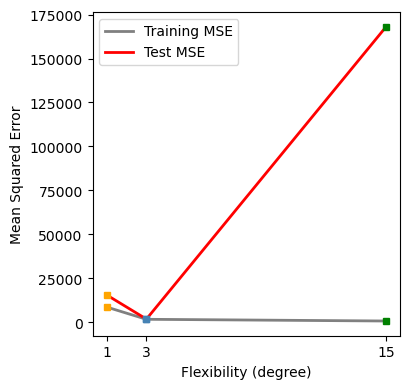

In [19]:
#| echo: false

np.random.seed(99)
n_test = 15
x_test = np.random.uniform(0, 100, n_test)
y_test = true_f(x_test) + np.random.normal(0, 50, n_test)

# Predictions on training and test sets
# Linear
y_hat_train_lin = lin_model.predict(x_obs.reshape(-1, 1))
y_hat_test_lin  = lin_model.predict(x_test.reshape(-1, 1))

# Degree 3
y_hat_train_3 = np.polyval(coeffs3, x_obs)
y_hat_test_3  = np.polyval(coeffs3, x_test)

# Degree 15 (using normalization)
x_test_norm = (x_test - t_min) / (t_max - t_min)
x_obs_norm  = (x_obs  - t_min) / (t_max - t_min)
y_hat_train_15 = np.polyval(coeffs15, x_obs_norm)
y_hat_test_15  = np.polyval(coeffs15, x_test_norm)

# MSEs
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

train_mses = [mse(y_obs, y_hat_train_lin),
              mse(y_obs, y_hat_train_3),
              mse(y_obs, y_hat_train_15)]

test_mses  = [mse(y_test, y_hat_test_lin),
              mse(y_test, y_hat_test_3),
              mse(y_test, y_hat_test_15)]

flexibility = [1, 3, 15]

colors = ['orange', 'steelblue', 'green']

plt.figure(figsize=(fig_size_x * 0.6, fig_size_y))
plt.plot(flexibility, train_mses, '-', color='gray', linewidth=2, label='Training MSE')
plt.plot(flexibility, test_mses,  '-', color='red',  linewidth=2, label='Test MSE')

for i, (f, c) in enumerate(zip(flexibility, colors)):
    plt.plot(f, train_mses[i], 's', color=c, markersize=5)
    plt.plot(f, test_mses[i],  's', color=c, markersize=5)

plt.xlabel('Flexibility (degree)')
plt.ylabel('Mean Squared Error')
#plt.ylabel('Mean Squared Error (log scale)')
#plt.yscale('log')
plt.xticks(flexibility, ['1', '3', '15'])
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()
plt.close()

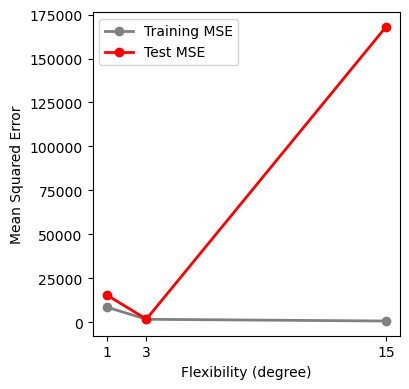

In [17]:
plt.figure(figsize=(fig_size_x * 0.6, fig_size_y))
plt.plot(flexibility, train_mses, 'o-', color='gray',  linewidth=2, label='Training MSE')
plt.plot(flexibility, test_mses,  'o-', color='red',   linewidth=2, label='Test MSE')
plt.xlabel('Flexibility (degree)')
plt.ylabel('Mean Squared Error')
plt.xticks(flexibility, ['1', '3', '15'])
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()
plt.close()

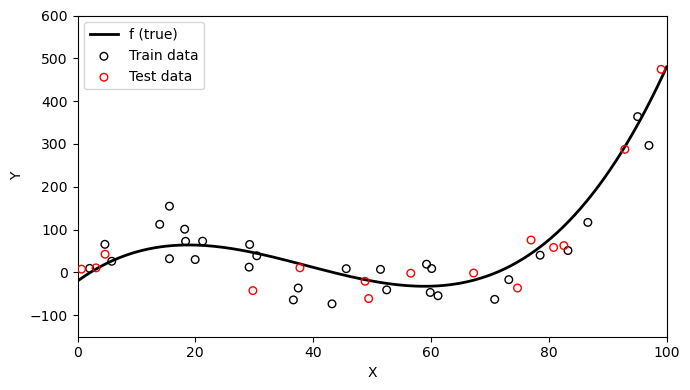

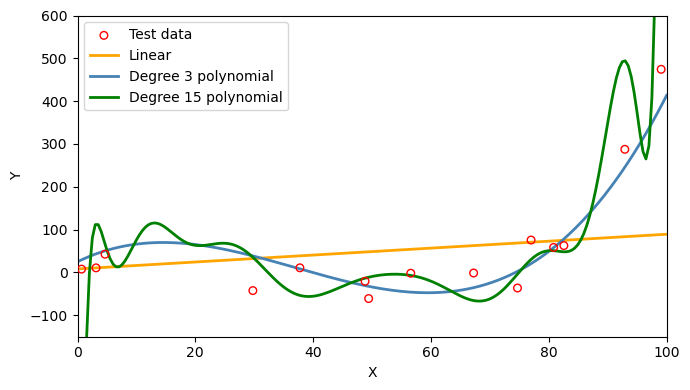

In [21]:
plt.figure(figsize=(fig_size_x, fig_size_y))
plt.plot(x, true_f(x),  'k-',          linewidth=2, label='f (true)')
plt.scatter(x_obs, y_obs, s=30, facecolors='none', edgecolors='black', zorder=5, label='Train data')
plt.scatter(x_test, y_test, s=30, facecolors='none', edgecolors='red', zorder=5, label='Test data')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
plt.close()

plt.figure(figsize=(fig_size_x, fig_size_y))
plt.scatter(x_test, y_test, s=30, facecolors='none', edgecolors='red', zorder=5, label='Test data')
plt.plot(x, y_linear,   color='orange',    linewidth=2, label='Linear')
plt.plot(x, y_poly3,    color='steelblue', linewidth=2, label='Degree 3 polynomial')
plt.plot(x, y_poly15,   color='green',     linewidth=2, label='Degree 15 polynomial')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

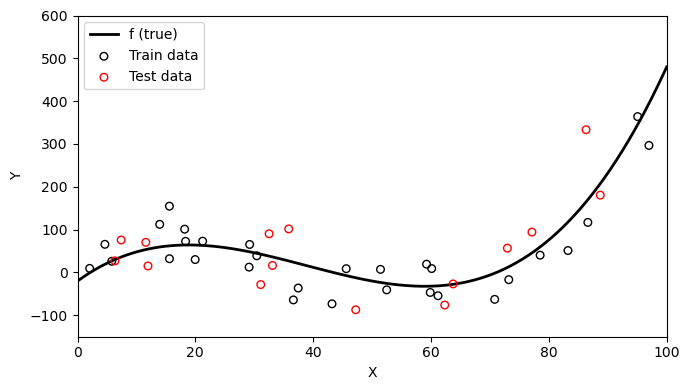

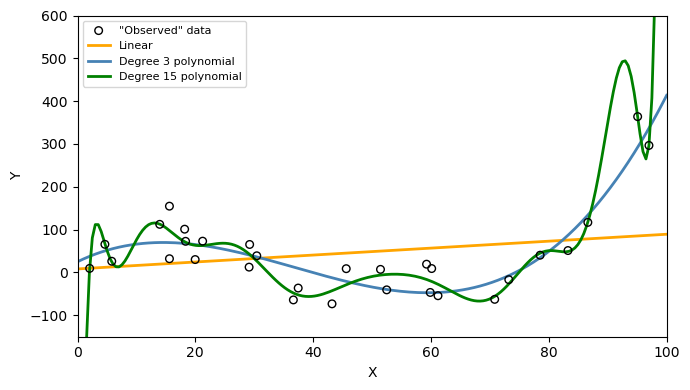

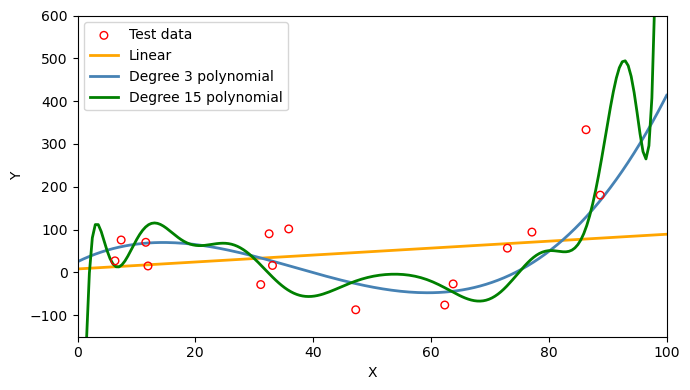

In [27]:
#| echo: false
np.random.seed(42)

# True function: third degree polynomial
def true_f(x):
    return 0.003*x**3 - 0.35*x**2 + 10*x - 20

# Create train set
n=30
x_obs = np.random.uniform(0, 100, n)
y_obs = true_f(x_obs) + np.random.normal(0, 50, n)

# Create test set
# np.random.seed(99)
n_test = 15
x_test = np.random.uniform(0, 100, n_test)
y_test = true_f(x_test) + np.random.normal(0, 50, n_test)

# # Three fits
# Linear fit
lin_model = LinearRegression()
lin_model.fit(x_obs.reshape(-1, 1), y_obs)
y_linear = lin_model.predict(x.reshape(-1, 1))

# Degree 3 polynomial (matches true f)
coeffs3 = np.polyfit(x_obs, y_obs, 3)
y_poly3 = np.polyval(coeffs3, x)

# Degree 15 polynomial (overfitting)
t_min, t_max = x_obs.min(), x_obs.max()
x_norm = (x_obs - t_min) / (t_max - t_min)
x_line_norm = (x - t_min) / (t_max - t_min)
coeffs15 = np.polyfit(x_norm, y_obs, 15)
y_poly15 = np.polyval(coeffs15, x_line_norm)


# Train and test data plot
x = np.linspace(0, 100, 200)
plt.figure(figsize=(fig_size_x, fig_size_y))
plt.plot(x, true_f(x),  'k-',          linewidth=2, label='f (true)')
plt.scatter(x_obs, y_obs, s=30, facecolors='none', edgecolors='black', zorder=5, label='Train data')
plt.scatter(x_test, y_test, s=30, facecolors='none', edgecolors='red', zorder=5, label='Test data')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
plt.close()

# Models with train data
plt.figure(figsize=(fig_size_x, fig_size_y))
plt.scatter(x_obs, y_obs, s=30, facecolors='none', edgecolors='black', zorder=5, label='"Observed" data')
plt.plot(x, y_linear,   color='orange',    linewidth=2, label='Linear')
plt.plot(x, y_poly3,    color='steelblue', linewidth=2, label='Degree 3 polynomial')
plt.plot(x, y_poly15,   color='green',     linewidth=2, label='Degree 15 polynomial')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

# Models with test data
plt.figure(figsize=(fig_size_x, fig_size_y))
plt.scatter(x_test, y_test, s=30, facecolors='none', edgecolors='red', zorder=5, label='Test data')
plt.plot(x, y_linear,   color='orange',    linewidth=2, label='Linear')
plt.plot(x, y_poly3,    color='steelblue', linewidth=2, label='Degree 3 polynomial')
plt.plot(x, y_poly15,   color='green',     linewidth=2, label='Degree 15 polynomial')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(0, 100)
plt.ylim(-150, 600)
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

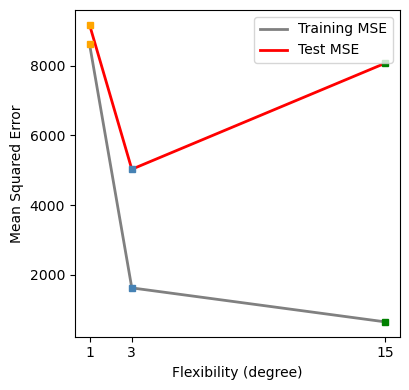

In [28]:

# Predictions on training and test sets
# Linear
y_hat_train_lin = lin_model.predict(x_obs.reshape(-1, 1))
y_hat_test_lin  = lin_model.predict(x_test.reshape(-1, 1))

# Degree 3
y_hat_train_3 = np.polyval(coeffs3, x_obs)
y_hat_test_3  = np.polyval(coeffs3, x_test)

# Degree 15 (using normalization)
x_test_norm = (x_test - t_min) / (t_max - t_min)
x_obs_norm  = (x_obs  - t_min) / (t_max - t_min)
y_hat_train_15 = np.polyval(coeffs15, x_obs_norm)
y_hat_test_15  = np.polyval(coeffs15, x_test_norm)

# MSEs
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

train_mses = [mse(y_obs, y_hat_train_lin),
              mse(y_obs, y_hat_train_3),
              mse(y_obs, y_hat_train_15)]

test_mses  = [mse(y_test, y_hat_test_lin),
              mse(y_test, y_hat_test_3),
              mse(y_test, y_hat_test_15)]

flexibility = [1, 3, 15]

colors = ['orange', 'steelblue', 'green']

plt.figure(figsize=(fig_size_x * 0.6, fig_size_y))
plt.plot(flexibility, train_mses, '-', color='gray', linewidth=2, label='Training MSE')
plt.plot(flexibility, test_mses,  '-', color='red',  linewidth=2, label='Test MSE')

for i, (f, c) in enumerate(zip(flexibility, colors)):
    plt.plot(f, train_mses[i], 's', color=c, markersize=5)
    plt.plot(f, test_mses[i],  's', color=c, markersize=5)

plt.xlabel('Flexibility (degree)')
plt.ylabel('Mean Squared Error')
#plt.ylabel('Mean Squared Error (log scale)')
#plt.yscale('log')
plt.xticks(flexibility, ['1', '3', '15'])
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()
plt.close()